# Battery Life Prediction for Solar System

This project uses **Artificial Intelligence and Machine Learning techniques only** to predict battery life in a solar power system using a Kaggle dataset.

## 1️ Problem Definition (AI/ML Perspective)
Predict battery life (in kwh) based on environmental and system parameters using supervised machine learning regression models.

## 2️ Import AI & ML Libraries

In [29]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 3️ Load Kaggle Dataset

Upload the Kaggle CSV file and update the filename below.

In [30]:

df = pd.read_csv("solar_output.csv")
df.head()


,Date,Temperature_C,Irradiance_W/m2,WindSpeed_m/s,Humidity_%,SolarOutput_kWh
0,2024-01-01,32.483571,458.462926,3.357787,41.710050,145.859229
1,2024-01-02,29.308678,557.935468,3.560785,44.398190,204.342949
2,2024-01-03,33.238443,565.728548,4.083051,57.472936,197.465684
3,2024-01-04,37.615149,519.772273,4.053802,56.103703,184.772057
4,2024-01-05,28.829233,583.871429,1.622331,49.790984,218.484633


## 4️ Data Preprocessing (ML Pipeline)

In [31]:

# Handle missing values
df = df.dropna()

# Feature & Target separation
X = df[['Temperature_C', 'Irradiance_W/m2', 'WindSpeed_m/s', 'Humidity_%']]
y = df['SolarOutput_kWh']

# Feature scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)


## 5️ Train-Test Split

In [32]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


## 6️ Machine Learning Model (AI-Based)

In [33]:

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

## 7️ Model Evaluation

In [34]:

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 16.544975652437223
RMSE: 19.062167543993777
R2 Score: 0.8776665491295021


## 8️ Feature Importance (Explainable AI)

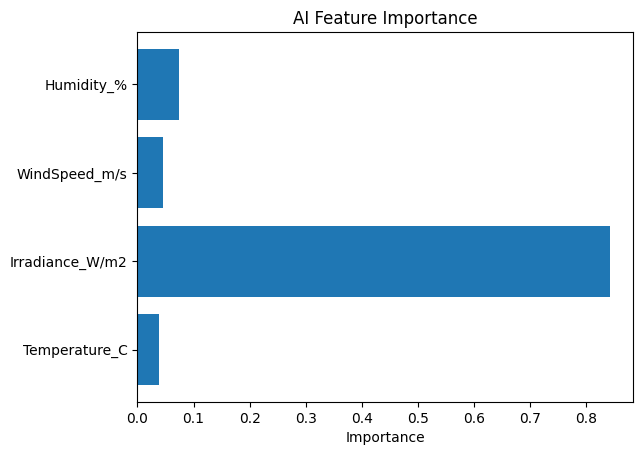

In [35]:

importances = model.feature_importances_
features = [
    'Temperature_C',
    'Irradiance_W/m2',
    'WindSpeed_m/s',
    'Humidity_%'
]
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("AI Feature Importance")
plt.show()


## 9️ AI-Based Prediction

In [36]:

# New solar system input
new_input = pd.DataFrame([{
    'Temperature_C': 35,
    'Irradiance_W/m2': 800,
    'WindSpeed_m/s': 4.5,
    'Humidity_%': 60
}])
prediction = model.predict(new_input)

print("Predicted Solar Output (kWh):", prediction[0])


Predicted Solar Output (kWh): 352.0904272678981
